In [53]:
# here we are simulating a subgraph concept of LangGraph where both parent and child graph have different state.

# In this method we build both graph differently and the subgraph will be invoked inside the parent node of that subgraph..

In [42]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [43]:
load_dotenv()

True

In [44]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [45]:
#child state
class TranslateState(TypedDict):
    input_text: str
    hin_translation: str

In [46]:
def translate_node(state: TranslateState):
    prompt = f"You are a helpful assistant. Translate the following answer in Hindi, Keep it clear, natural and don't add anything extra\n\nAnswer:{state["input_text"]}"
    translation = llm.invoke(prompt).content
    return {"hin_translation":translation}


In [47]:
subgraph_builder = StateGraph(TranslateState)

subgraph_builder.add_node("translate_node",translate_node)

subgraph_builder.add_edge(START,"translate_node")
subgraph_builder.add_edge("translate_node",END)

subgraph = subgraph_builder.compile()

In [48]:
class AnswerState(TypedDict):
    question:str
    answer:str
    translation:str

In [49]:
def answer_node(state: AnswerState):
    prompt = f"you are a helpful assistant, Answer this question:\n\nQuestion: {state['question']}"
    answer = llm.invoke(prompt).content
    return {"answer":answer}

In [50]:
def translate_answer_node(state:AnswerState):
    translate = subgraph.invoke({"input_text":state["answer"]})
    return {"translation":translate["hin_translation"]}

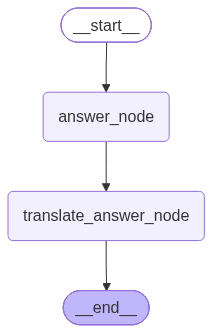

In [51]:
parent_builder = StateGraph(AnswerState)

parent_builder.add_node("answer_node",answer_node)
parent_builder.add_node("translate_answer_node",translate_answer_node)

parent_builder.add_edge(START,"answer_node")
parent_builder.add_edge("answer_node","translate_answer_node")
parent_builder.add_edge("translate_answer_node",END)

parent = parent_builder.compile()

parent

In [52]:
parent.invoke({"question":"who is prime minister of india?"})

{'question': 'who is prime minister of india?',
 'answer': 'The current Prime Minister of India is Narendra Modi. He has been serving as the Prime Minister of India since May 26, 2014.',
 'translation': 'भारत के वर्तमान प्रधानमंत्री नरेंद्र मोदी हैं। वे 26 मई, 2014 से भारत के प्रधानमंत्री के रूप में कार्यरत हैं।'}